## License
Copyright 2026 jphall@gwu.edu. MIT License; see the repository LICENSE file.

# NIST AI RMF action embeddings

Embeddings turn each RMF action into a numeric vector. This notebook creates a reusable embedding file for the RAG example, then projects a balanced sample into two dimensions with UMAP to illustrate the GOVERN, MAP, MEASURE, and MANAGE functions.

The input is `data/rmf_all_actions_redlined_tagged.xlsx` and the output is `data/rmf_action_embeddings.csv`.

## 1. Import packages and configure Azure


In [ ]:
# 1. Import packages and configure Azure
# Load data, plotting, UMAP, and Azure embedding dependencies.

from pathlib import Path
import json, os
from getpass import getpass
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import umap
from openai import AzureOpenAI

ROOT = Path.cwd().resolve()
if not (ROOT / "data").exists(): ROOT = ROOT.parent

SOURCE_FILE = ROOT / "data" / "rmf_all_actions_redlined_tagged.xlsx"
OUTPUT_FILE = ROOT / "data" / "rmf_action_embeddings.csv"

RESOURCE = "gw-sb-01"
ENDPOINT = f"https://{RESOURCE}.openai.azure.com/"

api_key = os.getenv("GW_AZURE_OPENAI_KEY") or getpass("Azure OpenAI API key: ")
client = AzureOpenAI(azure_endpoint=ENDPOINT, api_key=api_key, api_version="2025-03-01-preview")


## 2. Load and label RMF actions


In [ ]:
# 2. Load and label RMF actions
# Select the control identifier and action text used as embedding input.

actions = pd.read_excel(SOURCE_FILE)
actions.columns = [str(name).strip() for name in actions.columns]

control = next(name for name in actions.columns if "control" in name.lower())
action = next(name for name in actions.columns if name.lower() == "action")
actions = actions[[control, action]].dropna().rename(columns={control: "control_id", action: "action"})

# NIST uses MS (Measure), not ME, as the control-ID prefix.
functions = {"GV": "GOVERN", "MP": "MAP", "MS": "MEASURE", "MG": "MANAGE"}
actions["function"] = actions.control_id.str[:2].map(functions).fillna("OTHER")
actions.head()


,control_id,action,function
0,GV-1,"Policies, processes, procedures, and practices...",GOVERN
1,GV-1.1,Legal and regulatory requirements involving AI...,GOVERN
2,GV-1.2,The characteristics of trustworthy AI are inte...,GOVERN
3,GV-1.3,"Processes, procedures, and practices are in pl...",GOVERN
4,GV-1.4,The risk management process and its outcomes a...,GOVERN


## 3. Create and save embeddings


In [ ]:
# 3. Create and save embeddings
# Request vectors in small batches and save a reusable RAG dataset.

records = []

for start in range(0, len(actions), 50):

    batch = actions.iloc[start:start + 50]
    response = client.embeddings.create(model="text-embedding-3-small", input=batch.action.tolist())
    for row, item in zip(batch.itertuples(index=False), response.data):
        records.append({"control_id": row.control_id, "function": row.function, "action": row.action, "embedding": json.dumps(item.embedding)})

embeddings = pd.DataFrame(records)
embeddings.to_csv(OUTPUT_FILE, index=False)

print(f"Wrote {len(embeddings)} embeddings to {OUTPUT_FILE}")


Wrote 993 embeddings to /home/patrickh/Workspace/GWU_LLM_examples/data/rmf_action_embeddings.csv


## 4. Project a balanced sample with UMAP


/home/patrickh/Workspace/GWU_LLM_examples/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


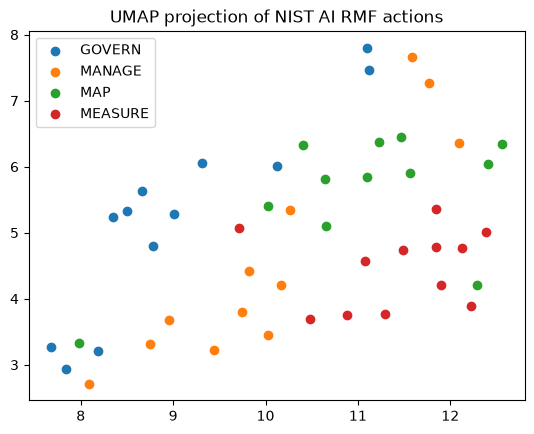

In [ ]:
# 4. Project a balanced sample with UMAP
# Visualize a small sample by NIST AI RMF function.

sample = embeddings.groupby("function", group_keys=False).head(12)
points = umap.UMAP(n_neighbors=8, min_dist=0.2, random_state=42).fit_transform(np.vstack(sample.embedding.map(json.loads)))

for name in sorted(sample.function.unique()):
    mask = sample.function == name
    plt.scatter(points[mask, 0], points[mask, 1], label=name)
    
plt.title("UMAP projection of NIST AI RMF actions")
plt.legend()
plt.show()
